In [ ]:
import sys, shutil
print(sys.executable)
print(shutil.which("mmseqs"))
from aguirre.config import PROJECT_ROOT, DATA_RAW
print(PROJECT_ROOT, DATA_RAW.exists())

In [ ]:
#==Importe==

import pandas as pd
import torch
import matplotlib.pyplot as plt
import numpy as np


In [72]:

%load_ext autoreload 
%autoreload 2 
#Updating von internen Paketen, ohne Kernelneustart
from aguirre.data import write_fasta
from aguirre.config import PROJECT_ROOT, DATA_RAW, DATA_DIR, Config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
DATA_DIR.mkdir(parents=True, exist_ok=True)   # Ordner anlegen, auch verschachtelt
print(DATA_RAW.exists())                      # True/False statt Exception

'Die Series ist ohne Duplicats (19670,) groß'

'Längste Sequenz ist 50'

'Kürzeste Sequenz ist 1'

Die 5. längsten Sequenzlängen sind:
|Sequenzlänge:     9 | Häufigkeit:       2154|
|Sequenzlänge:    12 | Häufigkeit:       1755|
|Sequenzlänge:    21 | Häufigkeit:       1070|
|Sequenzlänge:    13 | Häufigkeit:        901|
|Sequenzlänge:    20 | Häufigkeit:        863|
0                                      FFKKWPWWPWRRK
1                          RSVCRQIKICRRRGGCYYLCTNRPY
2        PKTLRKFFARIRGGRAAVLNALGKEEQIGRASNSGRKCARKKK
3                                  SNTALRRYNQWATGHFM
4                                          RCICVLGVC
                            ...                     
19665     AIVVGGVMLGIIAGKNSGVDEAFFVLKQHHVEYGSDHRFEAD
19666             ERECDTDADCQKKFPGSNQHLLWCNNGFCDCRTH
19667                                CRVPCNWKKEFGADC
19668                                      AKLVSRYKR
19669                   GIMDTVKGVAKTVAASLLDKLKCKITGC
Name: sequence, Length: 19670, dtype: str


/var/folders/bd/jt99k0p569j1j60f7kqyhhyr0000gn/T/ipykernel_42390/3034946624.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


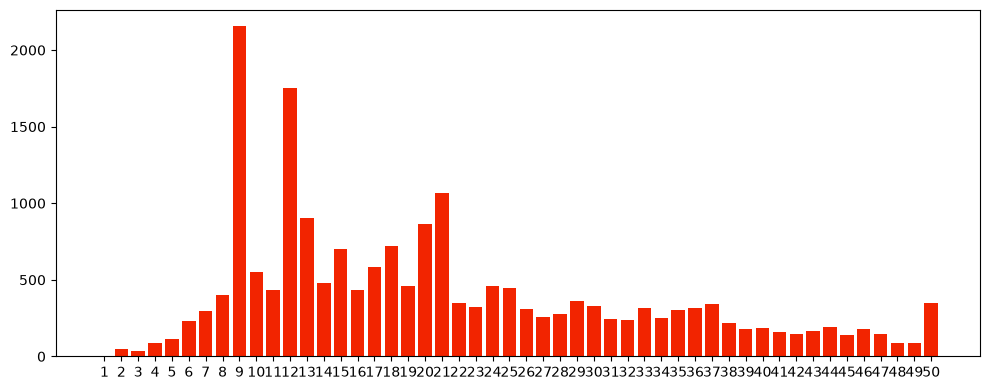

In [ ]:
#==CSV laden==
PATH = "Torres_Model/note/eval/train_eval.csv"

series = pd.read_csv(DATA_RAW)["sequence"]
series = series.drop_duplicates()
display(f"Die Series ist ohne Duplicats {series.shape} groß") #Duplicats anscheinend schon entfernt
display(f"Längste Sequenz ist {series.str.len().max()}")
display(f"Kürzeste Sequenz ist {series.str.len().min()}")

#==Längen und Längenhistogram==
längen = series.str.len().describe()
längen_sum_frequency = series.str.len().value_counts()
arr = längen_sum_frequency.reset_index().to_numpy()

print("Die 5. längsten Sequenzlängen sind:")
print(46*"=")
for i in range(5):
    print(f"|Sequenzlänge: {arr[i,0]:>5.0f} | Häufigkeit: {arr[i,1]:10.0f}|")
print(46*"=")

#==Plotten==
fig, ax = plt.subplots(1,1, figsize = (10,4))
ax.bar(arr[:,0], arr[:,1], color = "#f22400")
ax.set_xticks(arr[:, 0])
fig.tight_layout()
fig.show()

#==Alphabet prüfen==
cfg = Config()
kanonische_AS =cfg.AS_alphabet
maske = series.str.fullmatch(f"[{kanonische_AS}]+")

print(series[maske])

range(0, 5, 5)